In [1]:
import pyreadr
import pandas as pd
import numpy as np
import math
from collections import defaultdict, Counter
import os
from utils import plot_tree as pt
import webbrowser

# Caricamento dei dati dal file RDS
print("Caricamento dataset in corso...")
result = pyreadr.read_r('06_Cb_BTM_table.rds')
df = result[None]

# Filtraggio
ttype_selezionato = "ESAD"  #selezione del tumore
df_filtrato = df[df["ttype"] == ttype_selezionato].copy()

# Eliminazione geni sani (WT) e dati mancanti critici
df_filtrato = df_filtrato[df_filtrato['mutatation_status'] != "WT"]
df_filtrato = df_filtrato.dropna(subset=["clock_rank", "gene"])

print(f"Dataset filtrato per {ttype_selezionato}. Righe totali da analizzare: {len(df_filtrato)}")

df = df_filtrato[["sample_id","gene","clock_rank"]]

df.reset_index(drop=True, inplace=True)

Caricamento dataset in corso...
Dataset filtrato per ESAD. Righe totali da analizzare: 68


In [ ]:
print("number of patients",len(df["sample_id"].unique()))

number of patients 24


In [3]:
import collections

input = collections.defaultdict(dict)

all_genes = df["gene"].unique().to_numpy()

for sample_id in df["sample_id"].unique():
    df_sample = df[df["sample_id"]==sample_id]
    #print(sample_id," con ranks ", df_sample["clock_rank"].unique())
    for rank in df_sample["clock_rank"].unique():
        df_s_rank = df_sample[df_sample["clock_rank"] == rank]
        genes = df_s_rank["gene"].to_numpy()
        result = np.isin(all_genes,genes)
        input[rank][sample_id]=result

len(input[1].keys())

18

[1, 2, 4]


KeyError: 4

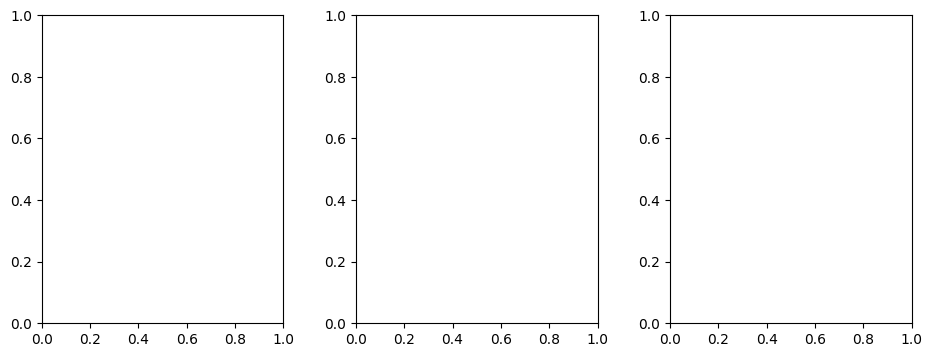

In [4]:
import utils.plot_patient_clustered
from utils.cluster import clusterize_patients

linkage = "average"
distance_metric = "jaccard"
best_k_metric = "silhouette"


distance_matrixes,labelsels = clusterize_patients(input, distance_metric, linkage, best_k_metric)


utils.plot_patient_clustered.plot(input, labelsels,distance_matrixes)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist
from sklearn.manifold import MDS
from scipy.cluster.hierarchy import dendrogram, linkage

real_input = np.array(list(input[1].values()))

distance_matrix = cdist(real_input, real_input, metric='jaccard')

hierarchical_cluster = AgglomerativeClustering(n_clusters=12,metric="precomputed", linkage='average')

labels = hierarchical_cluster.fit_predict(distance_matrix)

# 2. Reduce dimensions to 2D using MDS
mds = MDS(n_components=2, metric='precomputed', random_state=42)
X_2d = mds.fit_transform(distance_matrix)

# 3. Plot and color by cluster label
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', edgecolors='k', s=50)

plt.title("MDS Plot colored by Agglomerative Clusters")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

In [ ]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Convert your 2D square distance matrix back into a 1D condensed array
condensed_distances = squareform(distance_matrix)

# 2. Generate the linkage matrix
# (Use 'average' or 'complete' for Jaccard distances)
Z = linkage(condensed_distances, method='average')

# 2. Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=[f"Ind {i}" for i in range(len(X_2d))], leaf_rotation=90)

plt.title("Hierarchical Clustering Dendrogram (Jaccard Distance)")
plt.xlabel("Individual Index")
plt.ylabel("Distance Threshold")
plt.show()